# SpyCatcher Co-folding Analysis — Lead-Sensing Best Design

```
Best design (scaffold + SpyTag)  +  SpyCatcher001  +  Pb²⁺  →  RF3 co-fold
```

**Scientific question**: Does the best RFD3-designed scaffold, when fused to its SpyTag linker and
co-folded with SpyCatcher in the presence of Pb²⁺, simultaneously
(a) maintain the Pb-Cys3 coordination geometry, and
(b) present the SpyTag in a conformation that can engage SpyCatcher's binding groove?

**Design (96 aa, motif-scaffolding mode)**: Cys78, Cys113, and Cys122 from PbrR691 (5GPE) are
transplanted directly into chain A of the scaffold — no partner chains required for Pb²⁺ coordination.
The C-terminal `GSGSGSAHIVMVDAYKPTK` tag is appended here before RF3.

**SpyCatcher001** (PDB: 4MLI): Original SpyCatcher, crystal structure with SpyTag isopeptide bond
resolved at 1.5 Å. Used here both as the sequence input for the unbiased co-fold (Exp A) and as a
structural template to hold SpyCatcher in its bound conformation (Exp B).

**Two experimental conditions run in parallel**:

| | Exp A — de novo co-fold | Exp B — template-guided |
|---|---|---|
| Chain A | scaffold + SpyTag (seq) | scaffold + SpyTag (seq) |
| Chain B | SpyCatcher001 sequence | SpyCatcher001 structure (template) |
| Pb²⁺ | `ccd_code: PB` | `ccd_code: PB` |
| Question | Do they spontaneously co-fold? | Can SpyTag reach the binding groove? |

Each condition produces 5 diffusion models; best pose is selected by interface confidence (ipSAE A↔B).

**Key literature**:
- Huang et al., *Inorg. Chem.* 2016 — PbrR691 crystal structure (5GPE), hemidirected Pb-S₃ geometry
- Zakeri et al., *PNAS* 2012 — SpyTag/SpyCatcher isopeptide bond system
- Li et al., *J. Mol. Biol.* 2014 — Crystal structure of SpyCatcher-SpyTag complex (4MLI)


In [12]:
# --- Core ---
import os, sys, re, glob, json, math, shutil, gzip, urllib.request
from pathlib import Path
from copy import deepcopy

# --- Data / plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Locate the lead_sensoring project root ---
# This notebook lives in lead_sensoring/spycatcher/
NOTEBOOK_DIR = Path('/dtu/blackhole/09/214281/lead_sensoring/spycatcher')
PROJECT_ROOT = NOTEBOOK_DIR.parent           # lead_sensoring/
DESIGN_DIR   = PROJECT_ROOT / 'design'       # lead_sensoring/design/

if not DESIGN_DIR.is_dir():
    raise RuntimeError(f'Design directory not found: {DESIGN_DIR}. Check PROJECT_ROOT.')

# --- Add the shared helper library to sys.path ---
sys.path.insert(0, str(DESIGN_DIR / 'lib' / 'lib'))
import jupyter_utils
from rf3_metrics import gather_rf3_metrics

# --- Key directories ---
RESOURCES_DIR = NOTEBOOK_DIR / 'resources'
RESOURCES_DIR.mkdir(parents=True, exist_ok=True)

# --- SpyTag constants (same as Binder_design_course.ipynb) ---
SPYTAG_LINKER = 'GSGSGS'           # 6 aa flexible GS linker
SPYTAG_CORE   = 'AHIVMVDAYKPTK'   # 13 aa SpyTag (Zakeri et al. 2012)
SPYTAG        = SPYTAG_LINKER + SPYTAG_CORE   # 19 aa total

# --- Best design CIF (RFD3 + MPNN + RF3 validated backbone, motif-scaffolding mode) ---
BEST_DESIGN_CIF = RESOURCES_DIR / (
    'rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_r5_scaffold-side-15A_1_model_0__b1_d1_model_1.cif'
)
if not BEST_DESIGN_CIF.exists():
    raise RuntimeError(f'Best design CIF not found: {BEST_DESIGN_CIF}')

PLDDT_CUT    = 0.80   # pLDDT threshold for chain A (scaffold)
IPSAE_CUT    = 0.30   # ipSAE threshold for SpyTag-SpyCatcher interface

pd.set_option('display.max_columns', None)
print('Project root  :', PROJECT_ROOT)
print('Design dir    :', DESIGN_DIR)
print('Resources dir :', RESOURCES_DIR)
print('Best design   :', BEST_DESIGN_CIF.name)
print('SpyTag        :', SPYTAG, f'({len(SPYTAG)} aa)')
print('User          :', os.environ.get('USER', '?'))

Project root  : /dtu/blackhole/09/214281/lead_sensoring
Design dir    : /dtu/blackhole/09/214281/lead_sensoring/design
Resources dir : /dtu/blackhole/09/214281/lead_sensoring/spycatcher/resources
Best design   : rfd3_input_w6_scaffold-side-15A_5gpe_pb_motif_r5_scaffold-side-15A_1_model_0__b1_d1_model_1.cif
SpyTag        : GSGSGSAHIVMVDAYKPTK (19 aa)
User          : s243548


In [13]:
# --- Work directories for this analysis ---
WORK = NOTEBOOK_DIR / 'work' / 'cofold_exp01'

_subdirs = [
    'configs/rf3_A',   # Exp A: de novo co-fold JSON
    'configs/rf3_B',   # Exp B: template-guided JSON
    'submit',
    'logs',
    'rf3_out_A',
    'rf3_out_B',
    'scores',
]
for d in _subdirs:
    (WORK / d).mkdir(parents=True, exist_ok=True)

configs_A_dir = WORK / 'configs' / 'rf3_A'
configs_B_dir = WORK / 'configs' / 'rf3_B'
submit_dir    = WORK / 'submit'
logs_dir      = WORK / 'logs'
rf3_out_A_dir = WORK / 'rf3_out_A'
rf3_out_B_dir = WORK / 'rf3_out_B'
scores_dir    = WORK / 'scores'

print('Work root :', WORK)
for d in _subdirs:
    print(' ', WORK / d)

Work root : /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/configs/rf3_A
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/configs/rf3_B
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/submit
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/logs
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/rf3_out_A
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/rf3_out_B
  /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores


## 1. Parse best design — extract scaffold sequence

The CIF file is an RF3-validated RFD3 output in **motif-scaffolding mode**: chain A is a single
continuous polypeptide that already contains the transplanted Cys78, Cys113, and Cys122 from 5GPE.
There are no separate context chains and no explicit Pb²⁺ — the metal will be added as a CCD
ligand component in the RF3 input.

Expected: 96 aa, exactly 3 Cys residues at positions ~40, ~71, ~80.

In [14]:
# --- Shared helpers: robust mmCIF parser (handles both RCSB and RF3 column orders) ---
_AA3 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
}

def _cif_col_map(cif_path):
    """Return dict mapping _atom_site column names → 0-based index.
    Works for both RCSB-format and RF3-generated CIF/CIF.GZ files.
    """
    cols = {}
    idx  = 0
    in_atom_loop = False
    opener = gzip.open if str(cif_path).endswith('.gz') else open
    with opener(cif_path, 'rt') as fh:
        for line in fh:
            stripped = line.strip()
            if stripped == 'loop_':
                in_atom_loop = False
                idx = 0
            elif stripped.startswith('_atom_site.'):
                in_atom_loop = True
                key = stripped.split('_atom_site.')[1].split()[0]
                cols[key] = idx
                idx += 1
            elif in_atom_loop and (stripped.startswith('ATOM') or stripped.startswith('HETATM')):
                break
    return cols

def parse_cif_sequence(cif_path, chain='A'):
    """Extract one-letter sequence from a given chain by reading Cα atoms.
    Reads column positions dynamically from the mmCIF loop header.
    """
    cols   = _cif_col_map(cif_path)
    i_atom = cols.get('label_atom_id', 2)
    i_comp = cols.get('label_comp_id', 4)
    i_asym = cols.get('label_asym_id', 5)
    i_seq  = cols.get('label_seq_id',  7)
    n_min  = max(i_atom, i_comp, i_asym, i_seq)
    opener = gzip.open if str(cif_path).endswith('.gz') else open
    residues = {}
    with opener(cif_path, 'rt') as fh:
        for line in fh:
            if not line.startswith('ATOM'):
                continue
            parts = line.split()
            if len(parts) <= n_min:
                continue
            if parts[i_atom] == 'CA' and parts[i_asym] == chain and parts[i_seq] != '.':
                residues[int(parts[i_seq])] = _AA3.get(parts[i_comp], 'X')
    return ''.join(residues[i] for i in sorted(residues))

scaffold_seq = parse_cif_sequence(BEST_DESIGN_CIF, chain='A')

# --- Verify sequence length and Cys positions ---
cys_positions = [i + 1 for i, aa in enumerate(scaffold_seq) if aa == 'C']  # 1-indexed

print(f'Scaffold sequence ({len(scaffold_seq)} aa):')
print(scaffold_seq)
print()
print(f'Cys residues (1-indexed): {cys_positions}')

assert len(scaffold_seq) == 96, f'Expected 96 aa, got {len(scaffold_seq)}'
assert len(cys_positions) == 3, f'Expected 3 Cys, found {len(cys_positions)} at {cys_positions}'
print()
print('✓ 96 aa scaffold with exactly 3 Cys residues — matches expected motif-scaffolding design.')

Scaffold sequence (96 aa):
LTPLQRAAAAAFAAALPSSPVLQQLAADLQPWREQPELPCQPVNDLVKQYLAANAGDPALSAVLELLLSSCGENETVAECGIIRALELAAAQVAAA

Cys residues (1-indexed): [40, 71, 80]

✓ 96 aa scaffold with exactly 3 Cys residues — matches expected motif-scaffolding design.


## 2. Build chain A sequence (scaffold + SpyTag)

SpyTag `GSGSGSAHIVMVDAYKPTK` is appended C-terminally. The 6-residue GSGSGS linker provides
conformational freedom so the rigid Pb-binding domain and the surface anchor can move
independently — low pLDDT on the last ~19 residues in the RF3 output is **expected and
acceptable** (a flexible tag is what allows SpyCatcher binding).

The three Cys positions remain unchanged at their scaffold positions.

In [15]:
chain_a_seq = scaffold_seq + SPYTAG

# --- Annotate scaffold vs. SpyTag regions ---
n_scaffold = len(scaffold_seq)
n_total    = len(chain_a_seq)

print(f'Chain A (scaffold + SpyTag): {n_total} aa')
print(f'  Residues   1-{n_scaffold:>3d}: scaffold (Cys at {cys_positions})')
print(f'  Residues {n_scaffold+1:>3d}-{n_total:>3d}: {SPYTAG_LINKER} linker + SpyTag core')
print()
print('Full chain A:')
print(chain_a_seq)
print()
# Verify SpyTag is intact at C-terminus
assert chain_a_seq.endswith(SPYTAG), 'SpyTag not found at C-terminus!'
# Verify Cys positions unchanged
new_cys = [i + 1 for i, aa in enumerate(chain_a_seq) if aa == 'C']
assert new_cys == cys_positions, f'Cys positions changed: expected {cys_positions}, got {new_cys}'
print(f'✓ SpyTag appended correctly. Cys positions unchanged at {cys_positions}.')

Chain A (scaffold + SpyTag): 115 aa
  Residues   1- 96: scaffold (Cys at [40, 71, 80])
  Residues  97-115: GSGSGS linker + SpyTag core

Full chain A:
LTPLQRAAAAAFAAALPSSPVLQQLAADLQPWREQPELPCQPVNDLVKQYLAANAGDPALSAVLELLLSSCGENETVAECGIIRALELAAAQVAAAGSGSGSAHIVMVDAYKPTK

✓ SpyTag appended correctly. Cys positions unchanged at [40, 71, 80].


## 3. Prepare SpyCatcher001 (PDB: 4MLI)

**Why SpyCatcher001 from 4MLI?**  
4MLI (Li et al. 2014) is the first crystal structure of the SpyCatcher-SpyTag complex, resolved
at ~1.5 Å with the isopeptide bond between SpyCatcher Lys31 and SpyTag Asp7 visible. This
gives us SpyCatcher in its SpyTag-bound conformation — the most relevant state for predicting
whether our designed scaffold's C-terminal SpyTag can engage the binding groove.

**Two uses in this notebook:**
- **Exp A**: SpyCatcher01 chain sequence used as plain `seq` in the RF3 JSON — RF3 folds both
  chains freely from sequence alone (unbiased interface prediction).
- **Exp B**: Same CIF saved as structural template (`path`) — SpyCatcher held in its crystal
  conformation, scaffold chain predicted relative to it.

In [16]:
# --- Download 4MLI from RCSB PDB ---
pdb_id      = '4MLI'
pdb_url     = f'https://files.rcsb.org/download/{pdb_id}.cif'
pdb_cif_out = RESOURCES_DIR / f'{pdb_id}.cif'

if pdb_cif_out.exists():
    print(f'{pdb_cif_out.name} already downloaded, skipping.')
else:
    print(f'Downloading {pdb_id} from RCSB PDB...')
    try:
        urllib.request.urlretrieve(pdb_url, pdb_cif_out)
        print(f'Saved to {pdb_cif_out} ({pdb_cif_out.stat().st_size // 1024} KB)')
    except Exception as e:
        raise RuntimeError(
            f'Failed to download {pdb_id}: {e}\n'
            f'Please download manually:\n  wget {pdb_url} -O {pdb_cif_out}'
        )

# --- Parse all polypeptide chains from 4MLI (uses dynamic column detection) ---
def parse_all_chains_sequence(cif_path):
    """Return dict: asym_id -> one-letter sequence (polypeptide Cα residues only)."""
    cols   = _cif_col_map(cif_path)
    i_atom = cols.get('label_atom_id', 2)
    i_comp = cols.get('label_comp_id', 4)
    i_asym = cols.get('label_asym_id', 5)
    i_seq  = cols.get('label_seq_id',  7)
    n_min  = max(i_atom, i_comp, i_asym, i_seq)
    residues_by_chain = {}
    with open(cif_path) as fh:
        for line in fh:
            if not line.startswith('ATOM'):
                continue
            parts = line.split()
            if len(parts) <= n_min:
                continue
            if parts[i_atom] == 'CA' and parts[i_seq] != '.' and parts[i_comp] in _AA3:
                asym = parts[i_asym]
                if asym not in residues_by_chain:
                    residues_by_chain[asym] = {}
                residues_by_chain[asym][int(parts[i_seq])] = _AA3[parts[i_comp]]
    return {
        chain: ''.join(res[i] for i in sorted(res))
        for chain, res in residues_by_chain.items()
    }

chains_4mli = parse_all_chains_sequence(pdb_cif_out)
print(f'\nChains found in {pdb_id}:')
for ch, seq in sorted(chains_4mli.items(), key=lambda x: -len(x[1])):
    print(f'  Chain {ch}: {len(seq):>4d} aa  {seq[:50]}...')

4MLI.cif already downloaded, skipping.

Chains found in 4MLI:
  Chain B:   83 aa  DSATHIKFSKRDEDGKELAGATMELRDSSGKTISTWISDGQVKDFYLYPG...
  Chain A:   82 aa  DSATHIKFSKRDEDGKELAGATMELRDSSGKTISTWISDGQVKDFYLYPG...
  Chain C:   12 aa  AHIVMVDAYKPT...
  Chain D:   12 aa  AHIVMVDAYKPT...


In [17]:
# --- Identify SpyCatcher chain (longest polypeptide chain in 4MLI) ---
# SpyCatcher001 is ~116 aa; SpyTag peptide is ~13 aa.
spycatcher_chain_id = max(chains_4mli, key=lambda c: len(chains_4mli[c]))
SPYCATCHER001_SEQ   = chains_4mli[spycatcher_chain_id]

print(f'SpyCatcher chain: {spycatcher_chain_id} ({len(SPYCATCHER001_SEQ)} aa)')
print(f'Sequence: {SPYCATCHER001_SEQ}')
print()

# Sanity check: SpyCatcher should be >> 50 aa, should NOT contain SpyTag core
assert len(SPYCATCHER001_SEQ) > 50, f'Chain {spycatcher_chain_id} too short for SpyCatcher ({len(SPYCATCHER001_SEQ)} aa)'
if SPYTAG_CORE in SPYCATCHER001_SEQ:
    print('[WARNING] SpyTag core sequence found inside SpyCatcher — double-check chain assignment!')
print(f'✓ SpyCatcher001 identified: chain {spycatcher_chain_id}, {len(SPYCATCHER001_SEQ)} aa')

# --- Save SpyCatcher-only CIF for use as template in Exp B ---
# Extract only ATOM records from chain `spycatcher_chain_id` plus required CIF headers.
spycatcher_cif_out = RESOURCES_DIR / '4MLI_spycatcher_chain.cif'

with open(pdb_cif_out) as fh:
    raw_lines = fh.readlines()

# Use _cif_col_map to find the correct column index for label_asym_id in this CIF.
# RCSB CIF files have label_asym_id at index 6, NOT index 5 (index 5 is label_comp_id).
col_map = _cif_col_map(pdb_cif_out)
i_asym  = col_map.get('label_asym_id', 6)

# Collect all CIF header/loop lines up to ATOM records, then only SpyCatcher ATOMs
header_lines = []
atom_lines   = []
in_atom_loop = False

for line in raw_lines:
    if line.startswith('ATOM') or line.startswith('HETATM'):
        in_atom_loop = True
        parts = line.split()
        if line.startswith('ATOM') and len(parts) > i_asym and parts[i_asym] == spycatcher_chain_id:
            atom_lines.append(line)
    elif not in_atom_loop:
        header_lines.append(line)

with open(spycatcher_cif_out, 'w') as fh:
    fh.writelines(header_lines)
    fh.writelines(atom_lines)

n_atoms = len(atom_lines)
print(f'Saved SpyCatcher-only CIF: {spycatcher_cif_out.name} ({n_atoms} ATOM lines)')
assert n_atoms > 0, (
    f'No ATOM lines extracted for chain {spycatcher_chain_id}! '
    f'label_asym_id detected at column {i_asym}. Check col_map: {col_map}'
)

SpyCatcher chain: B (83 aa)
Sequence: DSATHIKFSKRDEDGKELAGATMELRDSSGKTISTWISDGQVKDFYLYPGKYTFVETAAPDGYEVATAITFTVNEQGQVTVNG

✓ SpyCatcher001 identified: chain B, 83 aa
Saved SpyCatcher-only CIF: 4MLI_spycatcher_chain.cif (672 ATOM lines)


## 4. Build RF3 input JSONs

**RF3 JSON format** (confirmed from existing pipeline):

```json
// Multi-chain with sequence only:
{"components": [{"seq": "...", "chain_id": "A"}, {"seq": "...", "chain_id": "B"}, {"ccd_code": "PB"}]}

// Multi-chain with structural template:
{"components": [{"seq": "...", "chain_id": "A"}, {"path": "path/to/structure.cif"}],
 "template_selection": ["B"]}
```

`{"ccd_code": "PB"}` instructs RF3 to include a free Pb²⁺ ion, which will be placed to
optimally coordinate with the three Cys residues in chain A.

Note: paths in `path` entries must be **absolute** to avoid ambiguity when RF3 runs
from the job working directory.

In [18]:
design_name = 'best_design_w6_15A_b1d1'

# --- Experiment A: pure sequence co-fold (both chains free) ---
rf3_json_A = {
    'name': f'spycatcher_cofold_A_{design_name}',
    'components': [
        {'seq': chain_a_seq,       'chain_id': 'A'},   # scaffold + SpyTag
        {'seq': SPYCATCHER001_SEQ, 'chain_id': 'B'},   # SpyCatcher001
        {'ccd_code': 'PB'},                            # Pb²⁺ ion
    ],
}

json_A_path = configs_A_dir / f'spycatcher_cofold_A_{design_name}.json'
with open(json_A_path, 'w') as fh:
    json.dump(rf3_json_A, fh, indent=2)

print('Exp A JSON written:', json_A_path.name)
print(json.dumps(rf3_json_A, indent=2)[:500], '...')

Exp A JSON written: spycatcher_cofold_A_best_design_w6_15A_b1d1.json
{
  "name": "spycatcher_cofold_A_best_design_w6_15A_b1d1",
  "components": [
    {
      "seq": "LTPLQRAAAAAFAAALPSSPVLQQLAADLQPWREQPELPCQPVNDLVKQYLAANAGDPALSAVLELLLSSCGENETVAECGIIRALELAAAQVAAAGSGSGSAHIVMVDAYKPTK",
      "chain_id": "A"
    },
    {
      "seq": "DSATHIKFSKRDEDGKELAGATMELRDSSGKTISTWISDGQVKDFYLYPGKYTFVETAAPDGYEVATAITFTVNEQGQVTVNG",
      "chain_id": "B"
    },
    {
      "ccd_code": "PB"
    }
  ]
} ...


In [19]:
# --- Experiment B: template-guided (SpyCatcher held in crystal conformation) ---
rf3_json_B = {
    'name': f'spycatcher_cofold_B_{design_name}',
    'components': [
        {'seq': chain_a_seq, 'chain_id': 'A'},     # scaffold + SpyTag
        {'path': str(spycatcher_cif_out)},         # SpyCatcher001 crystal structure (absolute path)
        {'ccd_code': 'PB'},                        # Pb²⁺ ion
    ],
    'template_selection': ['B'],  # chain B from the path CIF is used as structural template
}

json_B_path = configs_B_dir / f'spycatcher_cofold_B_{design_name}.json'
with open(json_B_path, 'w') as fh:
    json.dump(rf3_json_B, fh, indent=2)

print('Exp B JSON written:', json_B_path.name)
print(json.dumps(rf3_json_B, indent=2))

Exp B JSON written: spycatcher_cofold_B_best_design_w6_15A_b1d1.json
{
  "name": "spycatcher_cofold_B_best_design_w6_15A_b1d1",
  "components": [
    {
      "seq": "LTPLQRAAAAAFAAALPSSPVLQQLAADLQPWREQPELPCQPVNDLVKQYLAANAGDPALSAVLELLLSSCGENETVAECGIIRALELAAAQVAAAGSGSGSAHIVMVDAYKPTK",
      "chain_id": "A"
    },
    {
      "path": "/dtu/blackhole/09/214281/lead_sensoring/spycatcher/resources/4MLI_spycatcher_chain.cif"
    },
    {
      "ccd_code": "PB"
    }
  ],
  "template_selection": [
    "B"
  ]
}


## 5. Write LSF submit scripts

Each experiment gets its own LSF job. RF3 automatically produces 5 diffusion models per
input JSON (`model_0` through `model_4`) — this is the 'diffuse multiple times' step.

**Queue notes** (DTU HPC, LSF):
- Queue `c27666`, 1 exclusive MIG slice (~20 GB GPU RAM)
- `DISABLE_CUEQUIVARIANCE=true` required to prevent pynvml crash on MIG
- Wall time 2h is sufficient for a single two-chain complex

**After submission**, monitor with `bjobs` or `bstat`. When the job disappears from
`bstat`, check the log file for completion. Output files will appear in `rf3_out_A/`
and `rf3_out_B/`.

In [20]:
# --- RF3 execution settings ---
queue       = 'c27666'
cores       = 4
gpu_spec    = 'num=1:mode=exclusive_process'
time_limit  = '2:00'
mem         = '10GB'

rf3_release = '/dtu/projects/dbl/rf3/release'
ckpt_path   = f'{rf3_release}/ckpt/rf3_latest.pt'
rf3_wrapper = str(DESIGN_DIR / 'lib' / 'lib' / 'rf3_wrapper.py')
num_steps   = 50

def make_rf3_single_script(json_path, out_dir, job_name, submit_out):
    """Write a single-job (non-array) LSF script for one RF3 fold."""
    out_dir.mkdir(parents=True, exist_ok=True)
    fold_out_dir = out_dir / Path(json_path).stem
    cmd = (
        f'python {rf3_wrapper} fold inference_engine=rf3 '
        f'inputs={json_path} out_dir={fold_out_dir} '
        f'ckpt_path={ckpt_path} num_steps={num_steps} '
        f'annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0'
    )
    script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J.out
#BSUB -e {logs_dir}/%J.err

mkdir -p {logs_dir} {fold_out_dir}
module load cuda/12.4
source {rf3_release}/activate_env.sh
export DISABLE_CUEQUIVARIANCE=true
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

echo "Starting RF3 co-fold: {job_name}"
echo "Input  : {json_path}"
echo "Out dir: {fold_out_dir}"
echo "Started: $(date)"

{cmd}

echo "Finished: $(date)"
"""
    with open(submit_out, 'w') as fh:
        fh.write(script)
    return submit_out, fold_out_dir

# --- Write Exp A script ---
sub_A, fold_out_A = make_rf3_single_script(
    json_path  = json_A_path,
    out_dir    = rf3_out_A_dir,
    job_name   = f'rf3_sc_A_{design_name[:20]}',
    submit_out = submit_dir / 'rf3_expA.sh',
)

# --- Write Exp B script ---
sub_B, fold_out_B = make_rf3_single_script(
    json_path  = json_B_path,
    out_dir    = rf3_out_B_dir,
    job_name   = f'rf3_sc_B_{design_name[:20]}',
    submit_out = submit_dir / 'rf3_expB.sh',
)

print('=' * 65)
print('Submit Experiment A (de novo co-fold):')
print(f'  bsub < {sub_A}')
print()
print('Submit Experiment B (template-guided):')
print(f'  bsub < {sub_B}')
print('=' * 65)
print()
print('Monitor: bjobs    (or bstat when the cluster is quiet)')
print('Logs   :', logs_dir)
print()
print('Expected outputs after each job completes:')
print(f'  Exp A: {fold_out_A}/')
print(f'  Exp B: {fold_out_B}/')
print()
print('Each run produces 5 models: model_0.cif.gz ... model_4.cif.gz + one .score file.')

Submit Experiment A (de novo co-fold):
  bsub < /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/submit/rf3_expA.sh

Submit Experiment B (template-guided):
  bsub < /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/submit/rf3_expB.sh

Monitor: bjobs    (or bstat when the cluster is quiet)
Logs   : /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/logs

Expected outputs after each job completes:
  Exp A: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/rf3_out_A/spycatcher_cofold_A_best_design_w6_15A_b1d1/
  Exp B: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/rf3_out_B/spycatcher_cofold_B_best_design_w6_15A_b1d1/

Each run produces 5 models: model_0.cif.gz ... model_4.cif.gz + one .score file.


## 6. Score outputs — pLDDT and SpyTag-SpyCatcher interface (ipSAE)

**Chain IDs in the RF3 output CIF** (with multi-chain input):
- `A` — designed scaffold + SpyTag (our chain A)
- `B` — SpyCatcher (chain B from input)
- `C` or similar — Pb²⁺ ion

Note: `gather_rf3_metrics` uses the score file labels `A_1`/`B_1` internally (from the
`.score` JSON), which differ from the CIF `label_asym_id` values (`A`/`B`). Use chain
`'A'` when reading the CIF directly.

**Key metrics**:

| Metric | Source | Target |
|--------|--------|--------|
| `best_binder_plddt` (A_1) | Chain pLDDT | > 0.8 |
| `AF_best_min_pae` (A_1↔B_1) | Interface PAE [Å] | < 10 Å |
| `AF_ipsae_at_best` (A_1↔B_1) | ipSAE [0–1] | > 0.3 |

**ipSAE interpretation**: An ipSAE > 0.5 is a confident interface prediction. For
SpyTag-SpyCatcher, values > 0.3 suggest the tag can reach the binding groove. Low
ipSAE does not rule out binding — SpyTag is short and flexible, which can reduce
confidence even when the interaction is real.

In [21]:
# --- Score Experiment A ---
BINDER   = 'A_1'   # designed scaffold + SpyTag
TARGET_F = 'B_1'   # SpyCatcher (primary interface target)
TARGET_G = None    # Pb chain — not assessed as interface target here

csv_A = str(scores_dir / 'rf3_scores_expA.csv')

df_A = gather_rf3_metrics(
    parent   = str(rf3_out_A_dir),
    binder   = BINDER,
    target_f = TARGET_F,
    target_g = TARGET_G,
    out_csv  = csv_A,
)

if df_A.empty:
    print('[WARNING] No score files found in Exp A output dir — check that the RF3 job completed.')
    print(f'  Expected: {rf3_out_A_dir}')
else:
    print(f'Exp A: {len(df_A)} model(s) scored')
    print()
    print(df_A[['design_id', 'best_binder_plddt', 'AF_best_min_pae', 'AF_ipsae_at_best',
                'best_batch_idx']].to_string(index=False))

Wrote 1 records → /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/rf3_scores_expA.csv
Exp A: 1 model(s) scored

                                  design_id  best_binder_plddt  AF_best_min_pae  AF_ipsae_at_best  best_batch_idx
spycatcher_cofold_A_best_design_w6_15A_b1d1           0.816917         0.621527          0.785087               2


In [22]:
# --- Score Experiment B ---
csv_B = str(scores_dir / 'rf3_scores_expB.csv')

df_B = gather_rf3_metrics(
    parent   = str(rf3_out_B_dir),
    binder   = BINDER,
    target_f = TARGET_F,
    target_g = TARGET_G,
    out_csv  = csv_B,
)

if df_B.empty:
    print('[WARNING] No score files found in Exp B output dir — check that the RF3 job completed.')
    print(f'  Expected: {rf3_out_B_dir}')
else:
    print(f'Exp B: {len(df_B)} model(s) scored')
    print()
    print(df_B[['design_id', 'best_binder_plddt', 'AF_best_min_pae', 'AF_ipsae_at_best',
                'best_batch_idx']].to_string(index=False))

Wrote 1 records → /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/rf3_scores_expB.csv
Exp B: 1 model(s) scored

                                  design_id  best_binder_plddt  AF_best_min_pae  AF_ipsae_at_best  best_batch_idx
spycatcher_cofold_B_best_design_w6_15A_b1d1            0.87889         1.565888          0.305637               3


In [23]:
# --- Compare Exp A vs Exp B ---
rows = []
for label, df in [('A: de novo co-fold', df_A), ('B: template-guided', df_B)]:
    if df is None or df.empty:
        continue
    best = df.loc[df['AF_ipsae_at_best'].idxmax()] if 'AF_ipsae_at_best' in df.columns else df.iloc[0]
    rows.append({
        'Experiment':   label,
        'Best model':   int(best.get('best_batch_idx', -1)),
        'Scaffold pLDDT (A_1)': f"{best['best_binder_plddt']:.3f}",
        'Min PAE A↔B (Å)':      f"{best.get('AF_best_min_pae', float('nan')):.2f}",
        'ipSAE A↔B':            f"{best.get('AF_ipsae_at_best', float('nan')):.3f}",
    })

if rows:
    summary = pd.DataFrame(rows).set_index('Experiment')
    print('Best model per experiment (highest ipSAE):')
    print(summary.to_string())
else:
    print('No results to compare yet — run both experiments first.')

Best model per experiment (highest ipSAE):
                    Best model Scaffold pLDDT (A_1) Min PAE A↔B (Å) ipSAE A↔B
Experiment                                                                   
A: de novo co-fold           2                0.817            0.62     0.785
B: template-guided           3                0.879            1.57     0.306


## 7. Pb²⁺ coordination geometry — best model

Load the best-scoring model (highest ipSAE from Exp A) and verify that the Pb²⁺ ion
is coordinated by the three transplanted Cys residues.

**Expected values from PbrR691 WT (5GPE)**:
- Pb-S distances: 2.55–2.75 Å (EXAFS average ~2.67 Å)
- S-Pb-S angles: 80–100° (hemidirected geometry, not symmetric)
- Hemidirected: Pb lone-pair occupies one side, all three Cys on the other

If Pb-S distances are > 3.0 Å, the scaffold has diverged from the correct coordination
geometry — check the Cys positions in PyMOL/ChimeraX.

In [24]:
# --- Find best model CIF from Exp A ---
def find_best_model_cif(rf3_out_parent, df_scores):
    """Locate the CIF.GZ for the best-scoring model (highest ipSAE)."""
    if df_scores is None or df_scores.empty:
        return None
    best_row  = df_scores.loc[df_scores['AF_ipsae_at_best'].idxmax()]
    design_id = best_row['design_id']
    batch_idx = int(best_row['best_batch_idx'])
    cif_gz    = Path(rf3_out_parent) / design_id / f'{design_id}_model_{batch_idx}.cif.gz'
    if not cif_gz.exists():
        # Also try without batch subfolder (some RF3 versions write flat)
        cif_gz = Path(rf3_out_parent) / f'{design_id}_model_{batch_idx}.cif.gz'
    return cif_gz if cif_gz.exists() else None

best_cif_gz = find_best_model_cif(rf3_out_A_dir, df_A if 'df_A' in dir() and not df_A.empty else None)

if best_cif_gz is None:
    print('Best model CIF not found — run Exp A first and re-execute this cell.')
else:
    print(f'Best model: {best_cif_gz}')

Best model: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/rf3_out_A/spycatcher_cofold_A_best_design_w6_15A_b1d1/spycatcher_cofold_A_best_design_w6_15A_b1d1_model_2.cif.gz


In [25]:
# --- Parse Pb and Cys SG atoms from best model CIF (dynamic column detection) ---
def parse_pb_cys_geometry(cif_gz_path):
    """
    Extract Pb position and Cys SG positions from an RF3 output CIF (or CIF.GZ).
    Returns (pb_xyz, cys_sg_list) where cys_sg entries are (chain, seq_id, xyz_array).
    """
    cols    = _cif_col_map(cif_gz_path)
    i_group = cols.get('group_PDB',      0)
    i_elem  = cols.get('type_symbol',    1)
    i_atom  = cols.get('label_atom_id',  2)
    i_comp  = cols.get('label_comp_id',  4)
    i_asym  = cols.get('label_asym_id',  5)
    i_seq   = cols.get('label_seq_id',   7)
    i_x     = cols.get('Cartn_x',       17)
    i_y     = cols.get('Cartn_y',       18)
    i_z     = cols.get('Cartn_z',       19)
    n_min   = max(i_group, i_elem, i_atom, i_comp, i_asym, i_seq, i_x, i_y, i_z)

    pb_xyz = None
    cys_sg = []
    opener = gzip.open if str(cif_gz_path).endswith('.gz') else open

    with opener(cif_gz_path, 'rt') as fh:
        for line in fh:
            if not (line.startswith('ATOM') or line.startswith('HETATM')):
                continue
            parts = line.split()
            if len(parts) <= n_min:
                continue
            group   = parts[i_group]
            elem    = parts[i_elem]
            atom_id = parts[i_atom]
            comp_id = parts[i_comp]
            asym_id = parts[i_asym]
            seq_id  = parts[i_seq]
            x, y, z = float(parts[i_x]), float(parts[i_y]), float(parts[i_z])

            if comp_id == 'PB' or (elem == 'Pb' and group == 'HETATM'):
                pb_xyz = np.array([x, y, z])

            if comp_id == 'CYS' and atom_id == 'SG':
                cys_sg.append((asym_id, seq_id, np.array([x, y, z])))

    return pb_xyz, cys_sg


def compute_pb_geometry(pb_xyz, cys_sg_list):
    """Compute Pb-S distances and S-Pb-S angles."""
    records = []
    for ch, seqid, sg_xyz in cys_sg_list:
        dist = float(np.linalg.norm(sg_xyz - pb_xyz))
        records.append({'chain': ch, 'seq_id': seqid, 'Pb-S dist (Å)': round(dist, 3)})

    angles = []
    for i in range(len(cys_sg_list)):
        for j in range(i + 1, len(cys_sg_list)):
            v1 = cys_sg_list[i][2] - pb_xyz
            v2 = cys_sg_list[j][2] - pb_xyz
            cos_t = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9)
            angles.append(float(np.degrees(np.arccos(np.clip(cos_t, -1, 1)))))

    return pd.DataFrame(records), angles


if 'best_cif_gz' in dir() and best_cif_gz is not None:
    pb_xyz, cys_sg = parse_pb_cys_geometry(best_cif_gz)

    if pb_xyz is None:
        print('[NOTE] No Pb atom found in this model — RF3 may not have placed the metal ion.')
        print('       This can happen if the Pb coordination geometry is ambiguous.')
        print('       Check the CIF manually in PyMOL; try Exp B (template-guided) as well.')
    else:
        print(f'Pb position (xyz): {pb_xyz.round(2)}')
        print(f'CYS SG atoms found: {len(cys_sg)}')
        print()

        dist_df, spbs_angles = compute_pb_geometry(pb_xyz, cys_sg)

        print('Pb-S distances (WT target: 2.55–2.75 Å from 5GPE EXAFS):')
        print(dist_df.to_string(index=False))
        print()

        if spbs_angles:
            angle_str = ', '.join(f'{a:.1f}°' for a in spbs_angles)
            print(f'S-Pb-S angles (target: 80–100°): {angle_str}')

        if len(cys_sg) == 3:
            unit_vecs     = np.array([(sg[2] - pb_xyz) / np.linalg.norm(sg[2] - pb_xyz)
                                      for sg in cys_sg])
            centroid_norm = float(np.linalg.norm(unit_vecs.sum(axis=0)))
            print(f'Hemidirected score (ligand centroid norm): {centroid_norm:.3f}')
            if centroid_norm >= 0.45:
                print('  → Likely hemidirected Pb-S₃ geometry ✓ (matches PbrR691 WT)')
            elif centroid_norm >= 0.35:
                print('  → Ambiguous hemidirected geometry — inspect visually')
            else:
                print('  → Holodirected or ambiguous — may indicate geometry distortion')

        print()
        out_of_range = dist_df[dist_df['Pb-S dist (Å)'] > 3.0]
        if not out_of_range.empty:
            print('[WARNING] Some Pb-S distances > 3.0 Å — coordination geometry may be imperfect:')
            print(out_of_range.to_string(index=False))
        else:
            print('✓ All Pb-S distances ≤ 3.0 Å — within acceptable coordination range.')
else:
    print('No CIF to analyze — run Exp A first.')

Pb position (xyz): [ -9.42 -13.09 -13.91]
CYS SG atoms found: 3

Pb-S distances (WT target: 2.55–2.75 Å from 5GPE EXAFS):
chain seq_id  Pb-S dist (Å)
    A     40          2.413
    A     71          2.161
    A     80          2.590

S-Pb-S angles (target: 80–100°): 96.7°, 122.0°, 117.5°
Hemidirected score (ligand centroid norm): 0.885
  → Likely hemidirected Pb-S₃ geometry ✓ (matches PbrR691 WT)

✓ All Pb-S distances ≤ 3.0 Å — within acceptable coordination range.


## 8. Summary plots — per-model confidence and per-residue pLDDT

Use these plots to identify the most confident pose and to verify that the SpyTag
region (last 19 residues of chain A_1) is surface-exposed (expected: low pLDDT, flexible).

Plot saved: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/scaffold_plddt_vs_ipsae.png


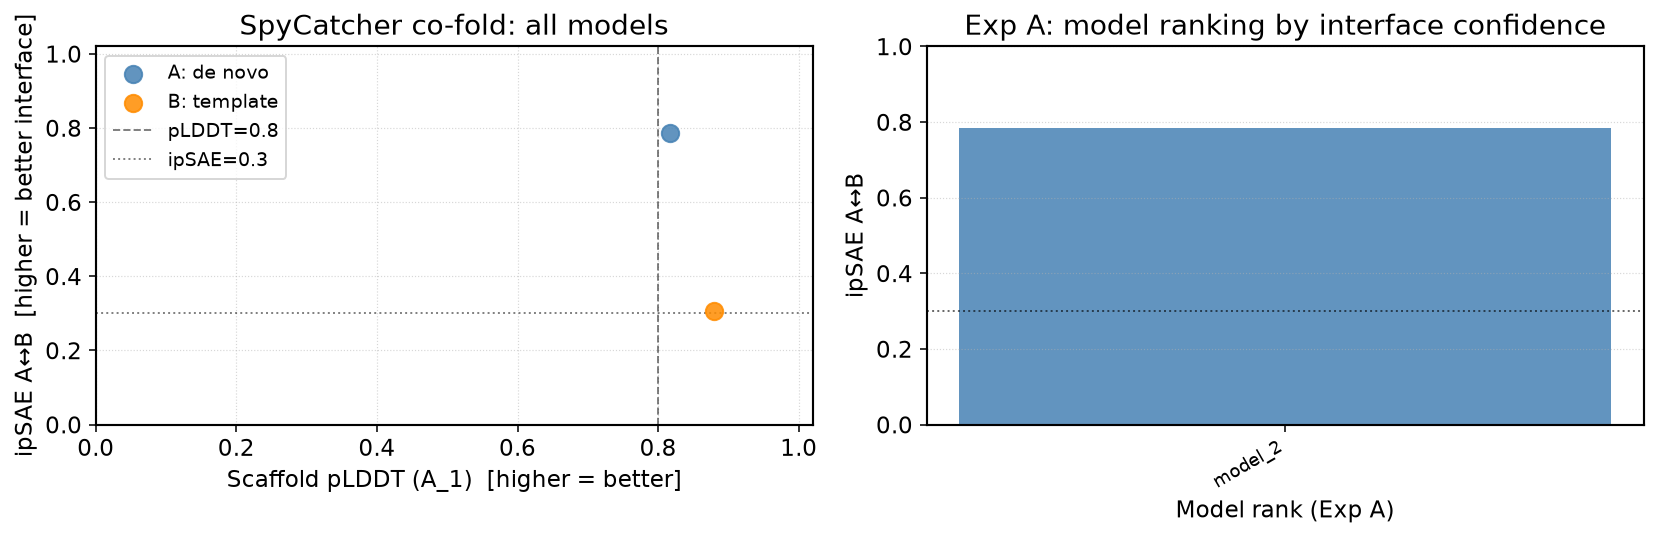

In [26]:
# --- Plot: ipSAE across all 5 models for Exp A and B ---
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12,
                     'axes.linewidth': 1.1, 'figure.dpi': 140})

dfs = []
if 'df_A' in dir() and not df_A.empty:
    df_A['experiment'] = 'A: de novo'
    dfs.append(df_A)
if 'df_B' in dir() and not df_B.empty:
    df_B['experiment'] = 'B: template'
    dfs.append(df_B)

if not dfs:
    print('No score data available yet — run RF3 jobs first.')
else:
    df_all = pd.concat(dfs, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: Scaffold pLDDT vs ipSAE scatter
    ax = axes[0]
    colors = {'A: de novo': 'steelblue', 'B: template': 'darkorange'}
    for exp, grp in df_all.groupby('experiment'):
        ax.scatter(grp['best_binder_plddt'], grp['AF_ipsae_at_best'],
                   label=exp, color=colors.get(exp, 'gray'), s=80, alpha=0.85, zorder=3)
    ax.axvline(PLDDT_CUT, ls='--', lw=1, color='black', alpha=0.5, label=f'pLDDT={PLDDT_CUT}')
    ax.axhline(IPSAE_CUT, ls=':',  lw=1, color='black', alpha=0.5, label=f'ipSAE={IPSAE_CUT}')
    ax.set_xlabel('Scaffold pLDDT (A_1)  [higher = better]')
    ax.set_ylabel('ipSAE A↔B  [higher = better interface]')
    ax.set_title('SpyCatcher co-fold: all models')
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)

    # Right: ipSAE bar chart (Exp A models ranked)
    ax2 = axes[1]
    if 'df_A' in dir() and not df_A.empty:
        ranked = df_A.sort_values('AF_ipsae_at_best', ascending=False).reset_index(drop=True)
        bars = ax2.bar(range(len(ranked)), ranked['AF_ipsae_at_best'],
                       color='steelblue', alpha=0.85)
        ax2.axhline(IPSAE_CUT, ls=':', lw=1, color='black', alpha=0.6)
        ax2.set_xlabel('Model rank (Exp A)')
        ax2.set_ylabel('ipSAE A↔B')
        ax2.set_title('Exp A: model ranking by interface confidence')
        ax2.set_xticks(range(len(ranked)))
        ax2.set_xticklabels([f"model_{int(r['best_batch_idx'])}" for _, r in ranked.iterrows()],
                             rotation=30, ha='right', fontsize=9)
        ax2.set_ylim(0, 1.0)
        ax2.grid(True, axis='y', linestyle=':', linewidth=0.6, alpha=0.5)

    fig.tight_layout()
    plot_path = scores_dir / 'scaffold_plddt_vs_ipsae.png'
    fig.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f'Plot saved: {plot_path}')
    plt.show()

Plot saved: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/best_model_plddt_ribbon.png


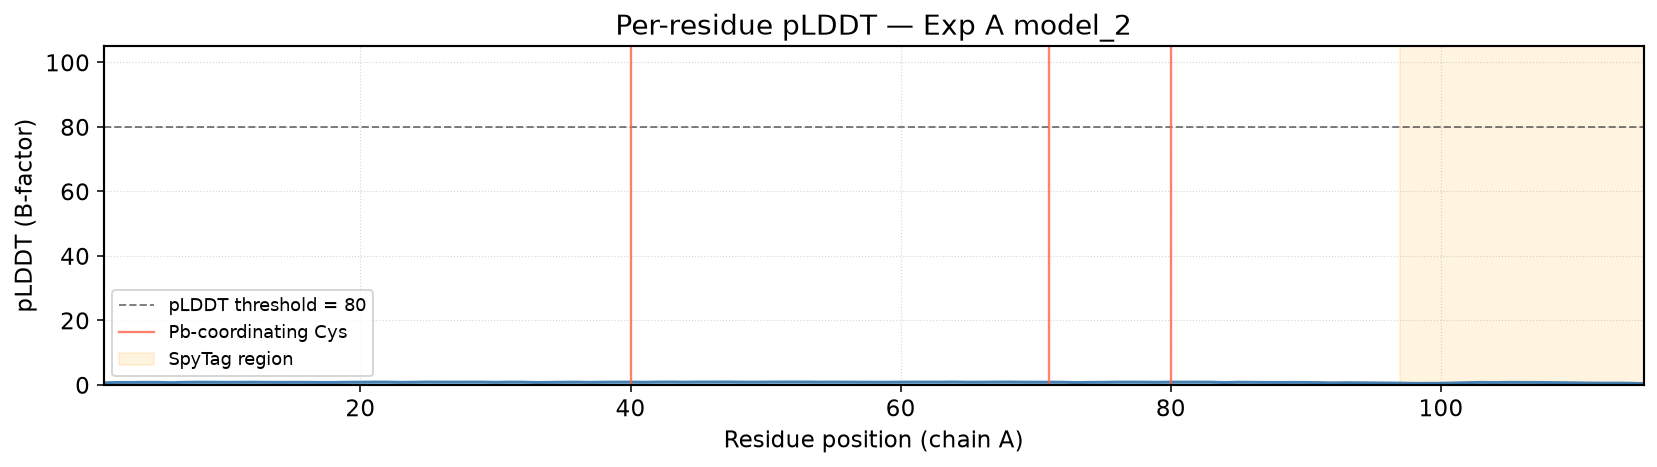


Mean pLDDT — scaffold: 0.8,  SpyTag linker: 0.6
  (SpyTag pLDDT < 70 is expected — a flexible disordered tag is what allows binding)


In [29]:
# --- Per-residue pLDDT ribbon for the best model ---
def parse_plddt_per_residue(cif_gz_path, chain='A'):
    """Extract per-residue average pLDDT (from B-factor) for one chain."""
    cols    = _cif_col_map(cif_gz_path)
    i_asym  = cols.get('label_asym_id',  5)
    i_seq   = cols.get('label_seq_id',   7)
    i_bfac  = cols.get('B_iso_or_equiv', 14)
    n_min   = max(i_asym, i_seq, i_bfac)
    opener  = gzip.open if str(cif_gz_path).endswith('.gz') else open
    residues = {}
    counts   = {}
    with opener(cif_gz_path, 'rt') as fh:
        for line in fh:
            if not line.startswith('ATOM'):
                continue
            parts = line.split()
            if len(parts) <= n_min:
                continue
            if parts[i_asym] == chain and parts[i_seq] != '.':
                rid = int(parts[i_seq])
                bfac = float(parts[i_bfac])
                residues[rid] = residues.get(rid, 0.0) + bfac
                counts[rid]   = counts.get(rid, 0) + 1
    if not residues:
        return None, None
    sorted_ids = sorted(residues)
    plddt_vals = [residues[i] / counts[i] for i in sorted_ids]
    return sorted_ids, plddt_vals


if 'best_cif_gz' in dir() and best_cif_gz is not None:
    res_ids, plddt_vals = parse_plddt_per_residue(best_cif_gz, chain='A')

    if res_ids:
        # Determine best model label safely
        if 'df_A' in dir() and df_A is not None and not df_A.empty:
            best_model_idx = int(df_A.loc[df_A['AF_ipsae_at_best'].idxmax(), 'best_batch_idx'])
            title_suffix   = f'model_{best_model_idx}'
        else:
            title_suffix = 'best model'

        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(res_ids, plddt_vals, color='steelblue', lw=1.5)
        ax.fill_between(res_ids, plddt_vals, alpha=0.25, color='steelblue')
        ax.axhline(PLDDT_CUT * 100, ls='--', lw=1, color='black', alpha=0.5,
                   label=f'pLDDT threshold = {int(PLDDT_CUT * 100)}')

        # Mark Cys positions (red verticals) — first one gets the legend label
        for k, cpos in enumerate(cys_positions):
            lbl = 'Pb-coordinating Cys' if k == 0 else '_nolegend_'
            ax.axvline(cpos, color='tomato', lw=1.2, alpha=0.8, ls='-', label=lbl)

        # Shade SpyTag region
        spy_start = n_scaffold + 1
        ax.axvspan(spy_start, max(res_ids), alpha=0.12, color='orange', label='SpyTag region')

        ax.set_xlabel('Residue position (chain A)')
        ax.set_ylabel('pLDDT (B-factor)')
        ax.set_title(f'Per-residue pLDDT — Exp A {title_suffix}')
        ax.set_xlim(min(res_ids), max(res_ids))
        ax.set_ylim(0, 105)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.5)
        fig.tight_layout()
        plddt_plot = scores_dir / 'best_model_plddt_ribbon.png'
        fig.savefig(plddt_plot, dpi=150, bbox_inches='tight')
        print(f'Plot saved: {plddt_plot}')
        plt.show()
        print()
        mean_scaffold = float(np.mean([plddt_vals[i] for i, rid in enumerate(res_ids)
                                        if rid <= n_scaffold]))
        mean_spytag   = float(np.mean([plddt_vals[i] for i, rid in enumerate(res_ids)
                                        if rid > n_scaffold]))
        print(f'Mean pLDDT — scaffold: {mean_scaffold:.1f},  SpyTag linker: {mean_spytag:.1f}')
        print('  (SpyTag pLDDT < 70 is expected — a flexible disordered tag is what allows binding)')
    else:
        print('Could not parse pLDDT from best model CIF — check chain ID A is present.')
else:
    print('Best model CIF not available — run Exp A and re-execute cells 20-24.')

## 9. Extract and visualize best pose

Decompress the best model CIF to a plain `.cif` file for visualization in PyMOL or ChimeraX.

**Recommended visualization steps in PyMOL/ChimeraX**:
1. Color chain A by B-factor (pLDDT): blue (high confidence) → red (low confidence)
2. Color SpyCatcher chain B in green
3. Show Pb²⁺ as a sphere (van der Waals, color yellow)
4. Show Cys SG atoms as sticks
5. Verify the SpyTag C-terminus of chain A points toward SpyCatcher's binding groove
6. Verify the three Cys form a triangle around the Pb²⁺ sphere

In [28]:
# --- Decompress best pose CIFs for visualization ---
def decompress_cif_gz(cif_gz, out_dir=None):
    out_dir  = Path(out_dir) if out_dir else Path(cif_gz).parent
    out_path = out_dir / Path(cif_gz).name.replace('.cif.gz', '.cif')
    with gzip.open(cif_gz, 'rb') as gz_in, open(out_path, 'wb') as out:
        out.write(gz_in.read())
    return out_path

best_cifs = {}
for exp_label, df_exp, out_parent in [
    ('A', df_A if 'df_A' in dir() and not df_A.empty else None, rf3_out_A_dir),
    ('B', df_B if 'df_B' in dir() and not df_B.empty else None, rf3_out_B_dir),
]:
    cif_gz = find_best_model_cif(out_parent, df_exp)
    if cif_gz is not None:
        cif_out = decompress_cif_gz(cif_gz, out_dir=scores_dir)
        best_cifs[exp_label] = cif_out
        print(f'Exp {exp_label} best pose: {cif_out}')
    else:
        print(f'Exp {exp_label}: no CIF found yet.')

print()
if best_cifs:
    print('Load in PyMOL/ChimeraX:')
    for exp_label, path in best_cifs.items():
        print(f'  Exp {exp_label}: {path}')

Exp A best pose: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/spycatcher_cofold_A_best_design_w6_15A_b1d1_model_2.cif
Exp B best pose: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/spycatcher_cofold_B_best_design_w6_15A_b1d1_model_3.cif

Load in PyMOL/ChimeraX:
  Exp A: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/spycatcher_cofold_A_best_design_w6_15A_b1d1_model_2.cif
  Exp B: /dtu/blackhole/09/214281/lead_sensoring/spycatcher/work/cofold_exp01/scores/spycatcher_cofold_B_best_design_w6_15A_b1d1_model_3.cif


## 10. Interpretation guide

### What to look for

| Observation | Interpretation |
|-------------|----------------|
| Scaffold pLDDT (A_1) > 0.80 | Scaffold fold is stable and well-defined |
| ipSAE A↔B > 0.30 | RF3 places SpyTag near SpyCatcher with confidence |
| ipSAE A↔B > 0.50 | Strong prediction of SpyTag-SpyCatcher interaction |
| SpyTag pLDDT < 0.70 | Expected — flexible tag, not structured before binding |
| Pb-S distances 2.3–2.9 Å | Pb²⁺ correctly coordinated by Cys triad |
| Hemidirected score ≥ 0.45 | Correct hemidirected Pb-S₃ geometry (matches PbrR691) |

### Agreement between Exp A and Exp B

- **Both high ipSAE**: Strong confidence that SpyTag engages SpyCatcher correctly.
- **Only Exp B high**: SpyCatcher template guides the interaction — the designed SpyTag
  geometry may be slightly suboptimal but covalent bond formation will still occur.
- **Both low ipSAE**: The SpyTag linker may be too short or the scaffold blocks access
  to the binding groove — consider adding more Gly-Ser linker residues.
- **Only Exp A high**: Rare; suggests RF3 finds a non-canonical binding pose.

### Next steps

1. **Visual inspection** in PyMOL/ChimeraX: check if SpyTag C-terminus is exposed
   and oriented toward SpyCatcher's reactive groove (Lys31 in SpyCatcher chain).
2. **RMSD of Cys triad** vs. 5GPE (Cys78/Cys113/Cys122): < 1.0 Å means the design
   preserves the exact coordination geometry.
3. **Expression and pull-down**: Express protein, incubate with SpyCatcher-coated beads,
   verify covalent isopeptide bond by SDS-PAGE (band shift).
4. **ITC or SPR**: Confirm Pb²⁺ binding affinity after SpyCatcher conjugation.